<a href="https://colab.research.google.com/github/polarpubhanu/nlp_1/blob/main/exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving SpotifyAudioFeaturesApril2019.csv to SpotifyAudioFeaturesApril2019.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/SpotifyAudioFeaturesApril2019.csv')
df.head()


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
features = [
    'danceability',
    'energy',
    'loudness',
    'acousticness',
    'valence',
    'tempo'
]

X = df[features]


In [ ]:
df['popularity_class'] = pd.qcut(
    df['popularity'],
    q=3,
    labels=['Low','Medium','High']
)

y = df['popularity_class']


In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model1 = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history1 = model1.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32
)


Epoch 1/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.4320 - loss: 1.0547 - val_accuracy: 0.4492 - val_loss: 1.0361
Epoch 2/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4514 - loss: 1.0352 - val_accuracy: 0.4481 - val_loss: 1.0363
Epoch 3/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4542 - loss: 1.0335 - val_accuracy: 0.4558 - val_loss: 1.0325
Epoch 4/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4587 - loss: 1.0285 - val_accuracy: 0.4533 - val_loss: 1.0325
Epoch 5/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4573 - loss: 1.0307 - val_accuracy: 0.4563 - val_loss: 1.0313
Epoch 6/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4610 - loss: 1.0273 - val_accuracy: 0.4522 - val_loss: 1.0326
Epoch 7/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4566 - loss: 1.0306 - val_accuracy: 0.4513 - val_loss: 1.0342
Epoch 8/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4630 - loss: 1.0255 - 

In [ ]:
y_pred1 = np.argmax(model1.predict(X_test), axis=1)

print("MODEL I REPORT")
print(classification_report(y_test, y_pred1))


817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MODEL I REPORT
              precision    recall  f1-score   support

           0       0.45      0.64      0.53      8235
           1       0.51      0.48      0.49      8911
           2       0.42      0.28      0.34      8987

    accuracy                           0.46     26133
   macro avg       0.46      0.47      0.45     26133
weighted avg       0.46      0.46      0.45     26133



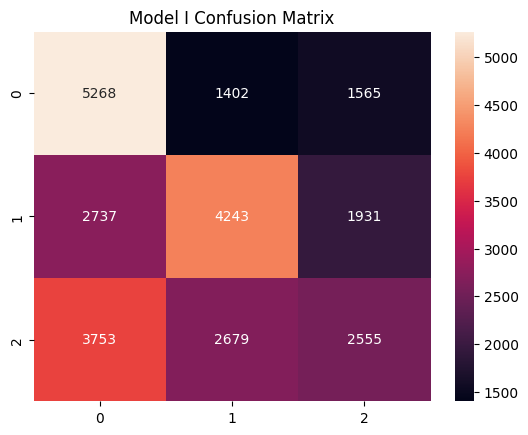

In [ ]:
cm1 = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm1, annot=True, fmt='d')
plt.title("Model I Confusion Matrix")
plt.show()


In [ ]:
!pip install keras-tuner



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 798.4 kB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential()

    for i in range(hp.Int('layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', 32, 128, step=32),
            activation=hp.Choice('activation', ['relu','tanh'])
        ))

    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2,1e-3,1e-4])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_dir',
    project_name='spotify_ann'
)

tuner.search(
    X_train, y_train,
    epochs=30,
    validation_split=0.2
)


Trial 5 Complete [00h 02m 00s]
val_accuracy: 0.4606333076953888

Best val_accuracy So Far: 0.4606333076953888
Total elapsed time: 00h 11m 06s


In [ ]:
best_model = tuner.get_best_models(1)[0]

history2 = best_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2614/2614 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.4707 - loss: 1.0162 - val_accuracy: 0.4545 - val_loss: 1.0345
Epoch 2/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4702 - loss: 1.0180 - val_accuracy: 0.4556 - val_loss: 1.0303
Epoch 3/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4715 - loss: 1.0164 - val_accuracy: 0.4583 - val_loss: 1.0294
Epoch 4/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4707 - loss: 1.0132 - val_accuracy: 0.4567 - val_loss: 1.0296
Epoch 5/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4731 - loss: 1.0145 - val_accuracy: 0.4535 - val_loss: 1.0325
Epoch 6/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4762 - loss: 1.0127 - val_accuracy: 0.4544 - val_loss: 1.0308
Epoch 7/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4736 - loss: 1.0163 - val_accuracy: 0.4553 - val_loss: 1.0314
Epoch 8/50
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4758 - loss: 1.0130 - val_accurac

In [ ]:
y_pred2 = np.argmax(best_model.predict(X_test), axis=1)

print("MODEL II REPORT")
print(classification_report(y_test, y_pred2))


817/817 ━━━━━━━━━━━━━━━━━━━━ 1s 700us/step
MODEL II REPORT
              precision    recall  f1-score   support

           0       0.45      0.62      0.52      8235
           1       0.49      0.51      0.50      8911
           2       0.43      0.25      0.32      8987

    accuracy                           0.46     26133
   macro avg       0.45      0.46      0.45     26133
weighted avg       0.45      0.46      0.44     26133



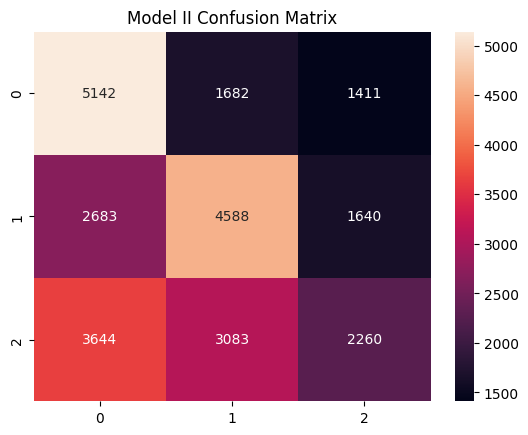

In [ ]:
cm2 = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm2, annot=True, fmt='d')
plt.title("Model II Confusion Matrix")
plt.show()


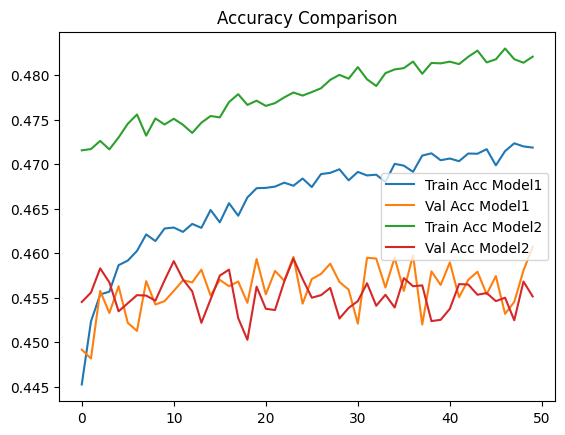

In [ ]:
plt.plot(history1.history['accuracy'], label='Train Acc Model1')
plt.plot(history1.history['val_accuracy'], label='Val Acc Model1')

plt.plot(history2.history['accuracy'], label='Train Acc Model2')
plt.plot(history2.history['val_accuracy'], label='Val Acc Model2')

plt.legend()
plt.title("Accuracy Comparison")
plt.show()


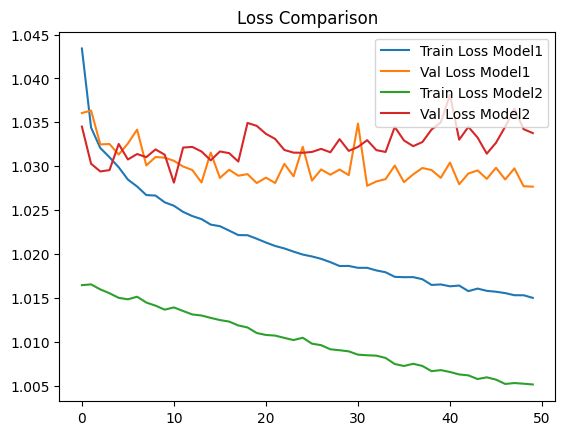

In [ ]:
plt.plot(history1.history['loss'], label='Train Loss Model1')
plt.plot(history1.history['val_loss'], label='Val Loss Model1')

plt.plot(history2.history['loss'], label='Train Loss Model2')
plt.plot(history2.history['val_loss'], label='Val Loss Model2')

plt.legend()
plt.title("Loss Comparison")
plt.show()
